# Example of creating a custom Dataset for PyGeometric

See [docs](https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_dataset.html)
See [Docs | Pairs of Graphs](https://pytorch-geometric.readthedocs.io/en/latest/advanced/batching.html#pairs-of-graphs)


In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
# Choose device (cuda if available, else cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

2.9.0+cu128
Selected device: cuda


# Example Custom Dataset Setup

Luckily, there is a new tutorial on how to include two graphs in one Data object (see [Pairs of Graphs](https://pytorch-geometric.readthedocs.io/en/latest/advanced/batching.html#pairs-of-graphs). We will follow along with that here to get a feel for how this works.

In [2]:
# Below is code produced by Gemini (Pro 2.5) to illustrate a pattern for how to achieve the batching we are looking for.
# NOTE: this seems easier/clearer than the official PyGeometric docs! Hopefully, this is correct :)
import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# --- 1. Create some dummy graph data ---
# Let's assume you have two lists of graphs and a list of labels
graph_list_1 = []
graph_list_2 = []
labels = []

for _ in range(10): # Create 10 dummy data points
    # Graph 1
    num_nodes_1 = torch.randint(5, 10, (1,)).item()
    edge_index_1 = torch.randint(0, num_nodes_1, (2, num_nodes_1 * 2))
    x_1 = torch.randn(num_nodes_1, 8)
    graph_list_1.append(Data(x=x_1, edge_index=edge_index_1))

    # Graph 2
    num_nodes_2 = torch.randint(5, 10, (1,)).item()
    edge_index_2 = torch.randint(0, num_nodes_2, (2, num_nodes_2 * 2))
    x_2 = torch.randn(num_nodes_2, 8)
    graph_list_2.append(Data(x=x_2, edge_index=edge_index_2))

    # Label
    labels.append(torch.rand(1))


# --- 2. Define your Dataset class ---
# This is the key part for you
class GraphPairDataset(Dataset):
    def __init__(self, g_list_1, g_list_2, label_list):
        super().__init__()
        self.g_list_1 = g_list_1
        self.g_list_2 = g_list_2
        self.label_list = label_list

    def len(self):
        return len(self.label_list)

    def get(self, idx):
        # Just return the tuple
        data_1 = self.g_list_1[idx]
        data_2 = self.g_list_2[idx]
        label = self.label_list[idx]
        return data_1, data_2, label

# --- 3. Use the Dataset and DataLoader ---
dataset = GraphPairDataset(graph_list_1, graph_list_2, labels)
loader = DataLoader(dataset, batch_size=4)

# Get the first batch
batch = next(iter(loader))

In [3]:
batch

[DataBatch(x=[30, 8], edge_index=[2, 60], batch=[30], ptr=[5]),
 DataBatch(x=[26, 8], edge_index=[2, 52], batch=[26], ptr=[5]),
 tensor([[0.0893],
         [0.2388],
         [0.0989],
         [0.1146]])]

In [4]:
batch[0][3]

Data(x=[9, 8], edge_index=[2, 18])

In [5]:
batch[0].batch

tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
        3, 3, 3, 3, 3, 3])

Cool, that seems to work! Now, let's try to adapt it to our specific data

# Custom Dataset for 2 graphs and label

In [6]:
## Load the colmap data
import pycolmap
import pathlib
import utils.subset
import random

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

random.seed(42) # for reproducibility

# Sample images into disjoint sets
a_ids, b_ids = utils.subset.sample_image_subsets(reconstruction)

# Convert the reconstruction data into two sub-graphs
graph_a = utils.subset.reconstruction_to_pyg_data(reconstruction, a_ids)
graph_b = utils.subset.reconstruction_to_pyg_data(reconstruction, b_ids)
[graph_a, graph_b]

[Data(x=[32, 3], edge_index=[2, 810]), Data(x=[33, 3], edge_index=[2, 940])]

In [30]:
# Example of creating a dataset via perturbations on one pair of graph subset
torch.manual_seed(42) # for reproducibility
perturbs = torch.empty(300, 3).uniform_(-10.0, 10.0) # We will create 80 examples
# Clone subgraph_b and perturb it for each data point
graph_a_list = []
graph_b_list = []
for perturbation in perturbs:
    new_graph = graph_b.clone()
    # Add the perturbation to the translation node features
    new_graph.x = new_graph.x + perturbation
    # Each example is [graph_a, graph_b, perturbation], where perturbation is our label
    graph_a_list.append(graph_a.clone()) # TODO should we clone this? I'll do it just to avoid any unforeseen bugs...
    graph_b_list.append(new_graph)

# Just to make it clearer what we are talking about
labels = perturbs

In [31]:
import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

class GraphPairDataset(Dataset):
    def __init__(self, g_list_1, g_list_2, label_list):
        assert(len(g_list_1) == len(g_list_2) and len(g_list_1) == len(label_list))
        super().__init__()
        self.g_list_1 = g_list_1
        self.g_list_2 = g_list_2
        self.label_list = label_list

    def len(self):
        return len(self.label_list)

    def get(self, idx):
        # Just return the tuple
        data_1 = self.g_list_1[idx]
        data_2 = self.g_list_2[idx]
        label = self.label_list[idx]
        return data_1, data_2, label

In [32]:
# Example of using our dataset, with batches!
dataset = GraphPairDataset(graph_a_list, graph_b_list, labels)
loader = DataLoader(dataset, batch_size=4)

# Get the first batch
batch = next(iter(loader))

Seems to be a success! Now, let's try a training loop.

In [33]:
from torch.utils.data import random_split
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = dataset_size - train_size
# Let's test the splitting utility
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [34]:
# And we create s distinct DataLoader for each dataset train and val
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [41]:
import numpy as np
from models import SiameseGCN_v1
from torch_geometric.loader import DataLoader
from tqdm import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

# dataset = GraphPairDataset(graph_a_list, graph_b_list, labels)
# loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Define model
model = SiameseGCN_v1(graph_a.num_features)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
criterion = torch.nn.MSELoss()

num_epochs = 400
# num_epochs = 200

# Keep track of loss
epoch_losses_train = []
epoch_losses_val = np.full(num_epochs, np.nan)  # one slot per epoch
with tqdm(range(num_epochs),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            # Move data to the GPU
            # batch = batch.to(device)
            graph_a_batch = batch[0].to(device)
            graph_b_batch = batch[1].to(device)
            label_batch   = batch[2].to(device)
            optimizer.zero_grad()
            # batch[0] is a batch of many graph_a graphs and batch[1] is a batch of many graph_b graphs
            out = model(graph_a_batch, graph_b_batch)
            # batch[2] is a batch of many labels
            loss = criterion(out, label_batch)
            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss += loss.item()
        avg_loss = train_loss / len(train_loader)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}' })
        # learning rate decay
        scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    label_batch   = batch[2].to(device)
                    out = model(graph_a_batch, graph_b_batch)
                    loss = criterion(out, label_batch)
                    val_loss += loss.item()
            epoch_losses_val[epoch] = val_loss / len(val_loader)

Selected device: cuda:0


Training progress: 100%|██████████| 400/400 [00:29<00:00, 13.47it/s, loss=28.4282]


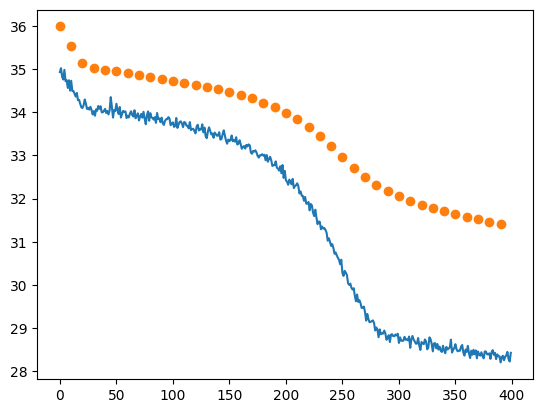

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()